# Lab1
**3230100885 王厚霖**

**Disclosure the use of AI**：Github Copilot (Agent, Claude Sonnet 4.6)

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# 配置 matplotlib 使用中文字体（SimHei 黑体，Windows 系统自带）
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

## Project 1: 图像生成

学习如何用程序生成灰度图像，并观察一些视觉现象。

目标:
1. 生成一幅 256x256 的平滑渐变灰度图像（灰度值从左到右为 0 到 255）。
2. 生成一幅 256x256 的分带渐变灰度图像（每带宽 16 像素，灰度值以 16 为步长递增）。
3. 观察并理解马赫带效应（Mach band effect）。

**第一步：平滑渐变图像（灰度 0 到 255）**

创建一幅 256x256 的灰度图像，其中每一列的灰度值相同，从左到右线性递增：最左列为 0（黑色），最右列为 255（白色）。

核心思路：用 `np.arange(256)` 生成一维数组 [0, 1, 2, ..., 255]，代表每列的灰度值。然后用 `np.tile` 将这一行在垂直方向复制 256 次，构成完整的 256x256 图像。即第 j 列的所有像素灰度值都等于 j。

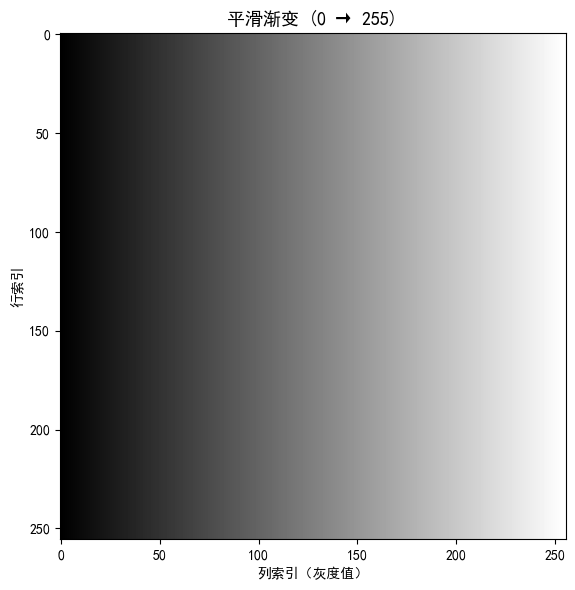

In [36]:
# ---------------------------------------------------------------------------
# 第一步 — 平滑渐变：从 0（左）到 255（右）
# ---------------------------------------------------------------------------

# 第 1 步：创建一维数组 [0, 1, 2, ..., 255] — 每列一个值
row = np.arange(256, dtype=np.uint8)          # 形状: (256,)

# 第 2 步：reshape 到 (1, 256) 并在垂直方向复制 256 次 → (256, 256)
# np.tile 沿指定维度重复数组。
# 这里将 1 行重复 256 次以获得完整的 256×256 图像。
smooth_gradient = np.tile(row, (256, 1))      # 形状: (256, 256)

# 第 3 步：显示平滑渐变图像
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(smooth_gradient, cmap='gray', vmin=0, vmax=255)
ax.set_title('平滑渐变 (0 → 255)', fontsize=13)
ax.set_xlabel('列索引（灰度值）')
ax.set_ylabel('行索引')
plt.tight_layout()
plt.show()

结果分析：
图像形状为 (256, 256)，数据类型为 uint8
左列像素值为 0（黑色），右列像素值为 255（白色），从左到右平滑递增，是一个理想的线性渐变图像。

**第二步：分带渐变图像（16 像素宽，步长 16）**

现在创建渐变图像的量化版本。图像不再平滑变化，而是被分成 16 个带，每带宽 16 像素，带内灰度值恒定：

  带号 0：列 0-15，   灰度值 0
  带号 1：列 16-31，  灰度值 16
  带号 2：列 32-47，  灰度值 32
  ...
  带号 15：列 240-255，灰度值 240

核心思路：对每个列索引 `j`，先做整数除法 `j // 16` 得到带号，再乘以步长 16 得到该带的灰度值。例如 `j=20` 时，`带号 = 20 // 16 = 1`，`灰度值 = 1 x 16 = 16`。

图像形状    : (256, 256)
唯一灰度值  : [  0  16  32  48  64  80  96 112 128 144 160 176 192 208 224 240]
带数        : 16


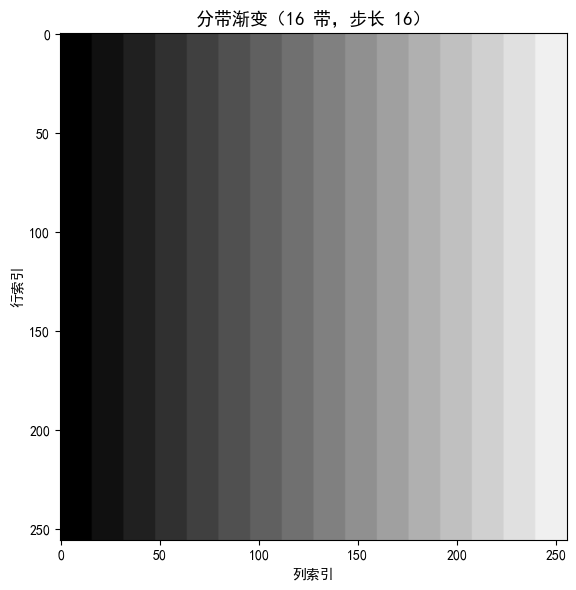

In [37]:
# ---------------------------------------------------------------------------
# 第二步 — 分带渐变：16 个带，每带宽 16 像素，步长 16
# ---------------------------------------------------------------------------

band_width = 16   # 每个恒定灰度带的宽度（像素）
step = 16         # 相邻带之间的灰度增量

# 第 1 步：对每个列索引 j（0-255），计算其带号：j // 16
#          然后乘以步长得到灰度值。
#          例如：列 0-15 → 带号 0 → 灰度值 0
#                列 16-31 → 带号 1 → 灰度值 16  ...以此类推。
row_banded = (np.arange(256) // band_width * step).astype(np.uint8)

# 第 2 步：垂直复制构建 256×256 图像（与第一步相同的方法）
banded_gradient = np.tile(row_banded, (256, 1))

print(f"图像形状    : {banded_gradient.shape}")
print(f"唯一灰度值  : {np.unique(banded_gradient)}")
print(f"带数        : {len(np.unique(banded_gradient))}")

# 第 3 步：显示分带渐变图像
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(banded_gradient, cmap='gray', vmin=0, vmax=255)
ax.set_title('分带渐变（16 带，步长 16）', fontsize=13)
ax.set_xlabel('列索引')
ax.set_ylabel('行索引')
plt.tight_layout()
plt.show()

**第三步：并排对比与马赫带效应**

将平滑渐变和分带渐变放在一起对比时，分带图像中的马赫带效应会非常明显。

马赫带效应是物理学家恩斯特·马赫发现的一种视觉错觉。在两个亮度不同但各自均匀的区域交界处，人眼会感知到：
  - 较亮一侧的边缘处出现一条更亮的条纹
  - 较暗一侧的边缘处出现一条更暗的条纹
尽管实际灰度值在每个带内是完全恒定的。

产生原因：视网膜中的侧抑制机制——相邻感光细胞会互相抑制，导致大脑在边缘处夸大了亮度对比。

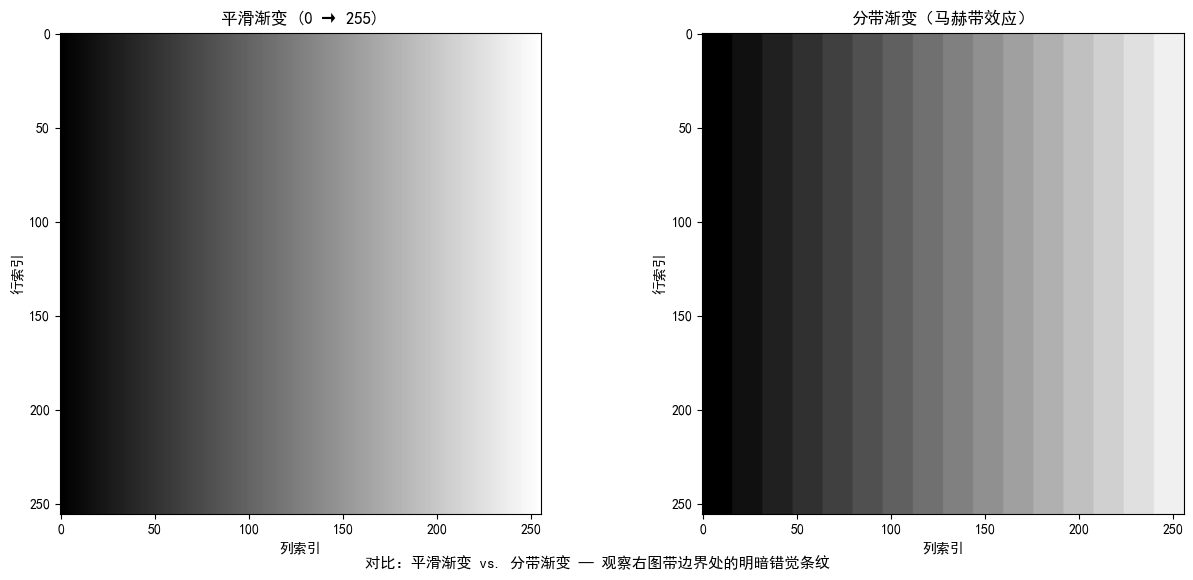

In [38]:
# ---------------------------------------------------------------------------
# 第三步 — 并排对比，观察马赫带效应
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# 左图：平滑渐变
axes[0].imshow(smooth_gradient, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('平滑渐变 (0 → 255)', fontsize=12)
axes[0].set_xlabel('列索引')
axes[0].set_ylabel('行索引')

# 右图：分带渐变 — 观察每个带边界处的马赫带
axes[1].imshow(banded_gradient, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('分带渐变（马赫带效应）', fontsize=12)
axes[1].set_xlabel('列索引')
axes[1].set_ylabel('行索引')

plt.suptitle('对比：平滑渐变 vs. 分带渐变 — 观察右图带边界处的明暗错觉条纹',
             fontsize=11, y=0.02)
plt.tight_layout()
plt.show()

观察各带交界处，能看到微弱的亮暗条纹，尽管每个带的灰度值实际上是完全均匀的。

**第四步：灰度剖面——证明带内灰度确实是平坦的**

为了确认马赫带效应纯粹是一种视觉错觉，绘制两幅图像中某一行的实际灰度值曲线。可以看到：
  - 平滑渐变的剖面是一条完美的直线。
  - 分带渐变的剖面是一个完美的阶梯函数，每个台阶内部绝对平坦，交界处没有任何亮暗突变。

因为马赫带错觉的存在，在观察时会在带边界处看到亮度变化。

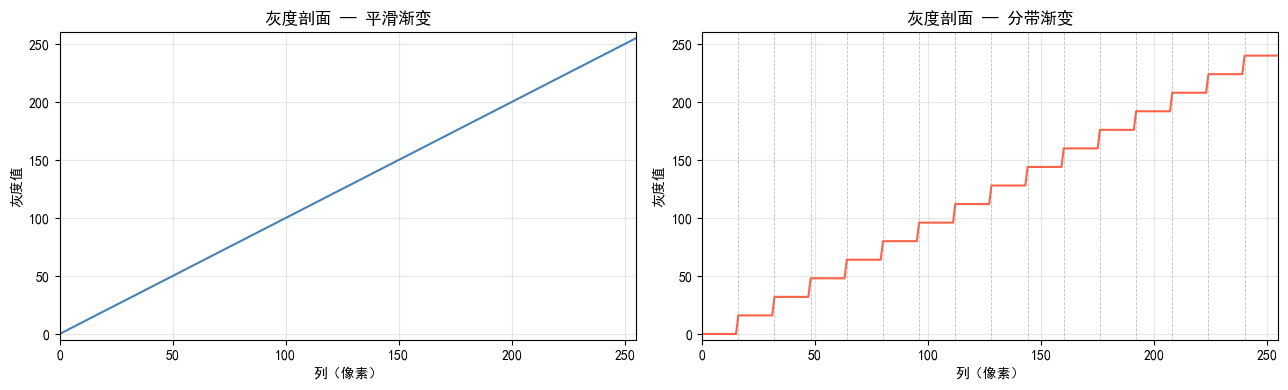

In [39]:
# ---------------------------------------------------------------------------
# 第四步 — 绘制灰度剖面，验证图像数据的正确性
# ---------------------------------------------------------------------------

# 从两幅图像中取一行（第 128 行）— 所有行都相同
row_idx = 128

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 平滑渐变的灰度剖面
axes[0].plot(smooth_gradient[row_idx, :], color='steelblue', linewidth=1.5)
axes[0].set_title('灰度剖面 — 平滑渐变')
axes[0].set_xlabel('列（像素）')
axes[0].set_ylabel('灰度值')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(-5, 260)
axes[0].grid(True, alpha=0.3)

# 分带渐变的灰度剖面 — 阶梯状，带内完全平坦
axes[1].plot(banded_gradient[row_idx, :], color='tomato', linewidth=1.5)
axes[1].set_title('灰度剖面 — 分带渐变')
axes[1].set_xlabel('列（像素）')
axes[1].set_ylabel('灰度值')
axes[1].set_xlim(0, 255)
axes[1].set_ylim(-5, 260)
axes[1].grid(True, alpha=0.3)

# 在带边界处绘制竖直虚线以便观察
for b in range(1, 16):
    axes[1].axvline(x=b * 16, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)

plt.tight_layout()
plt.show()

观察得出结论：分带渐变的剖面是完美的阶梯函数而非差异。

综上，通过这组实验实现了：实践图像的基本生成方式，并且观察马赫带的现象。

## Project 2: 灰度级别（Intensity Levels）

在本单元中，学习如何将一幅灰度图像的灰度级别从 256 级降低到任意 $2^n$ 级，并观察不同灰度级别下图像质量的变化。

目标:
1. 读入 `lab1.npy`（或 `lab1.mat`）中的图像数据。
2. 编写函数 `y = f(x, n)`，将图像的灰度级别降低到 $2^n$ 级。
3. 分别以 256 级（$n=8$）、64 级（$n=6$）和 16 级（$n=4$）显示图像，观察量化效果。

原理说明:
原始图像的像素值范围为 0-255，共 $256 = 2^8$ 个灰度级。如果想将灰度级减少到 $2^n$ 个，需要进行"灰度量化"操作。
具体步骤：
  1. 将原始像素值 `x`（范围 0-255）除以 256，归一化到 $[0, 1)$ 区间。
  2. 乘以 $2^n$，得到范围 $[0, 2^n)$ 的值。
  3. 取整（floor），得到 0 到 $2^n - 1$ 之间的整数，即量化后的灰度级编号。
  4. 重新映射回 0-255 范围以便显示：乘以 $255 / (2^n - 1)$。
公式: $y = floor(x / 256 * 2^n) * (255 / (2^n - 1))$
当 $n=8$ 时，$2^n = 256$，量化后的图像与原图完全相同。
当 $n$ 越小，灰度级越少，图像出现越明显的"伪轮廓"（false contouring）现象。


**第一步：读入图像数据**

图像形状: (361, 361)
数据类型: float64
像素值范围: [2.0, 255.0]


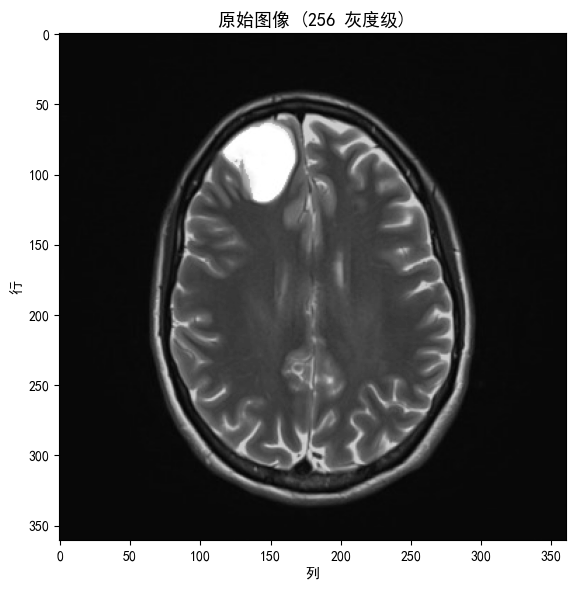

In [40]:
# ---------------------------------------------------------------------------
# 第一步：读入图像数据
# ---------------------------------------------------------------------------
# 支持两种格式：lab1.npy 和 lab1.mat
# np.load 用于读取 .npy 文件，scipy.io.loadmat 用于读取 .mat 文件

import scipy.io

# 方式一：从 .npy 文件读取
image_npy = np.load('lab1.npy')

# 方式二：从 .mat 文件读取（mat 文件中可能包含多个变量，取第一个非下划线开头的变量）
mat_data = scipy.io.loadmat('lab1.mat')
# mat_data 是一个字典，键名以下划线开头的是元信息，过滤掉它们
mat_keys = [k for k in mat_data.keys() if not k.startswith('_')]
image_mat = mat_data[mat_keys[0]]

# 选用 npy 文件中的数据作为后续处理的图像
image = image_npy.astype(np.float64)

print(f"图像形状: {image.shape}")
print(f"数据类型: {image.dtype}")
print(f"像素值范围: [{image.min()}, {image.max()}]")

# 显示原始图像
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap='gray', vmin=0, vmax=255)
ax.set_title('原始图像 (256 灰度级)', fontsize=13)
ax.set_xlabel('列')
ax.set_ylabel('行')
plt.tight_layout()
plt.show()

**第二步：定义灰度量化函数 $y = f(x, n)$**

函数接受两个参数：
  `x` -- 输入图像（像素值范围 `0-255`）
  `n` -- 目标灰度级别数的指数，即量化后共有 $2^n$ 个灰度级

量化过程详解：
  1. $x / 256$ 将像素值归一化到 $[0, 1)$ 区间
  2. 乘以 $2^n$ 后取整，得到 `0` 到 $2^n-1$ 之间的量化级别编号
  3. 再乘以 $255/(2^n-1)$，将量化后的级别重新映射回 `0-255` 范围用于显示

当 $n=8$ 时，$2^8=256$ 级，量化后图像与原图几乎无区别。
当 $n=6$ 时，$2^6=64$ 级，开始能看到轻微的灰度跳变。
当 $n=4$ 时，$2^4=16$ 级，伪轮廓现象非常明显。

In [41]:
# ---------------------------------------------------------------------------
# 第二步：定义灰度量化函数 y = f(x, n)
# ---------------------------------------------------------------------------

def reduce_gray_levels(x, n):
    """
    将图像的灰度级别降低到 2^n 级。
    
    参数:
        x : numpy 数组，输入图像，像素值范围 0-255
        n : 整数，目标灰度级别为 2^n
    
    返回:
        y : numpy 数组，量化后的图像，像素值仍映射到 0-255 范围
    """
    num_levels = 2 ** n  # 量化后的灰度级别总数，例如 n=4 时为 16
    
    # 步骤 1: 归一化到 [0, 1)，然后量化到 [0, num_levels) 并取整
    # np.floor 向下取整，确保结果是整数级别编号
    quantized = np.floor(x / 256.0 * num_levels)
    
    # 步骤 2: 将级别编号限制在合法范围 [0, num_levels-1] 内
    # 防止边界情况（例如像素值恰好为 255 时）
    quantized = np.clip(quantized, 0, num_levels - 1)
    
    # 步骤 3: 将量化后的级别编号重新映射回 0-255 范围
    # 这样显示时仍然使用完整的灰度范围
    if num_levels > 1:
        y = quantized * (255.0 / (num_levels - 1))
    else:
        y = np.zeros_like(x)  # 只有 1 级时，整幅图全黑
    
    return y.astype(np.uint8)

# 简单验证：n=8 时应该得到接近原图的结果
test_result = reduce_gray_levels(image, 8)
print(f"n=8 时量化后的唯一灰度值数量: {len(np.unique(test_result))} (应接近 256)")
print(f"n=4 时量化后的唯一灰度值数量: {len(np.unique(reduce_gray_levels(image, 4)))} (应接近 16)")
print(f"n=1 时量化后的唯一灰度值数量: {len(np.unique(reduce_gray_levels(image, 1)))} (应为 2)")

n=8 时量化后的唯一灰度值数量: 228 (应接近 256)
n=4 时量化后的唯一灰度值数量: 15 (应接近 16)
n=1 时量化后的唯一灰度值数量: 2 (应为 2)


**第三步：分别以 256 级、64 级和 16 级显示图像**

下面调用 `reduce_gray_levels` 函数，分别用 `n=8`（256级）、`n=6`（64级）、`n=4`（16级）对原始图像进行量化，
并将三幅结果图像并排显示。

依据理论知识，可能可以观察到下面的现象：
  - `n=8`（256 级）：与原图视觉上没有区别，因为保留了全部灰度信息。
  - `n=6`（64 级）：灰度过渡区域开始出现轻微的阶梯感。
  - `n=4`（16 级）：出现非常明显的"伪轮廓"现象，原本平滑的灰度过渡变成了可见的色块边界。这种伪轮廓在灰度变化缓慢的区域（如天空、皮肤）最容易被察觉。

n=8 (256 级): 实际使用了 228 个灰度值
  灰度值列表: [  2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19
  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37
  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55
  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73
  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91
  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109
 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127
 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145
 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163
 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181
 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199
 200 201 202 203 204 231 232 233 234 235 236 237 238 239 240 241 242 243
 244 245 246 247 248 249 250 251 252 253 254 255]

n=6 (64 级): 实际使用了 59 个灰度值
  灰度值列表: [

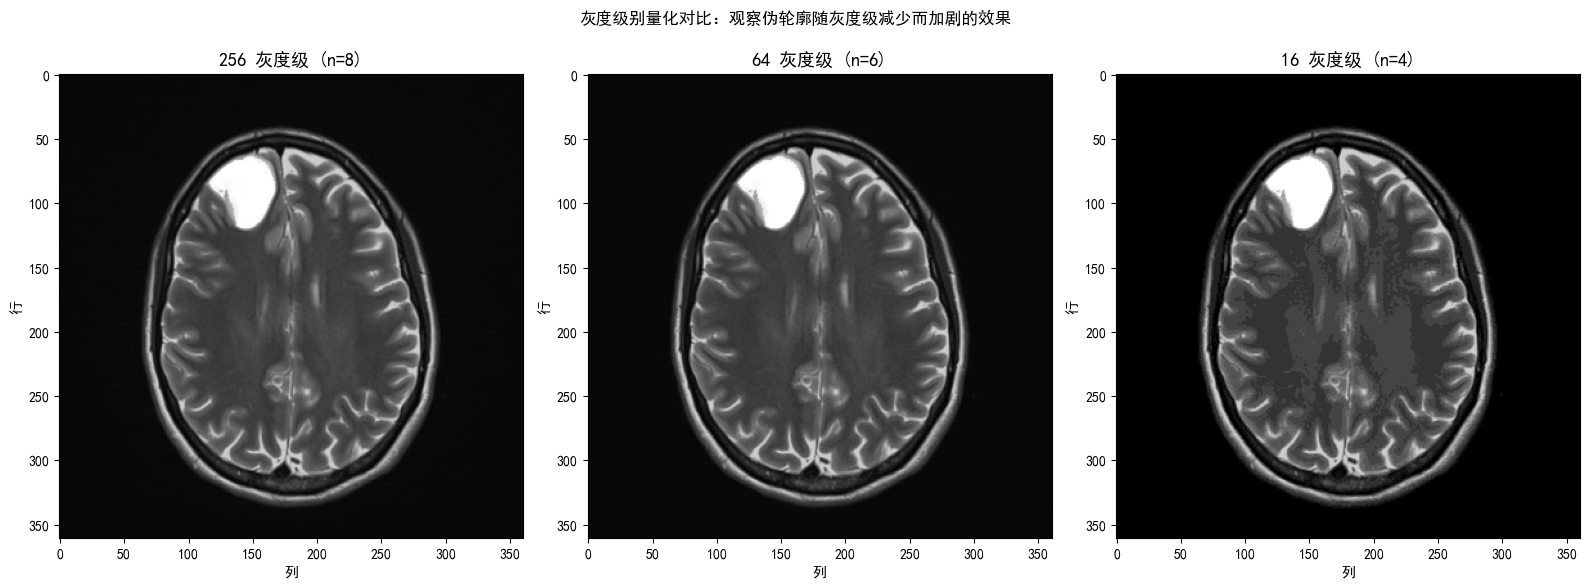

In [42]:
# ---------------------------------------------------------------------------
# 第三步：以 256 级、64 级和 16 级显示图像
# ---------------------------------------------------------------------------

# 定义要展示的三种灰度级别
levels = [
    (8, 256),   # n=8, 2^8 = 256 级
    (6, 64),    # n=6, 2^6 = 64 级
    (4, 16),    # n=4, 2^4 = 16 级
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

for idx, (n, num_levels) in enumerate(levels):
    # 调用量化函数
    quantized_image = reduce_gray_levels(image, n)
    
    # 显示量化后的图像
    axes[idx].imshow(quantized_image, cmap='gray', vmin=0, vmax=255)
    axes[idx].set_title(f'{num_levels} 灰度级 (n={n})', fontsize=13)
    axes[idx].set_xlabel('列')
    axes[idx].set_ylabel('行')
    
    # 打印量化信息
    unique_vals = np.unique(quantized_image)
    print(f"n={n} ({num_levels} 级): 实际使用了 {len(unique_vals)} 个灰度值")
    print(f"  灰度值列表: {unique_vals}")
    print()

plt.suptitle('灰度级别量化对比：观察伪轮廓随灰度级减少而加剧的效果', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**扩展实验：使用更多灰度级别进行对比**

为了更完整地展示灰度量化的效果，额外展示 n=1 到 n=8 的全部量化结果。
随着 n 从 8 减小到 1，灰度级别从 256 逐步降到 2，可以清晰地看到图像质量的逐步退化过程。

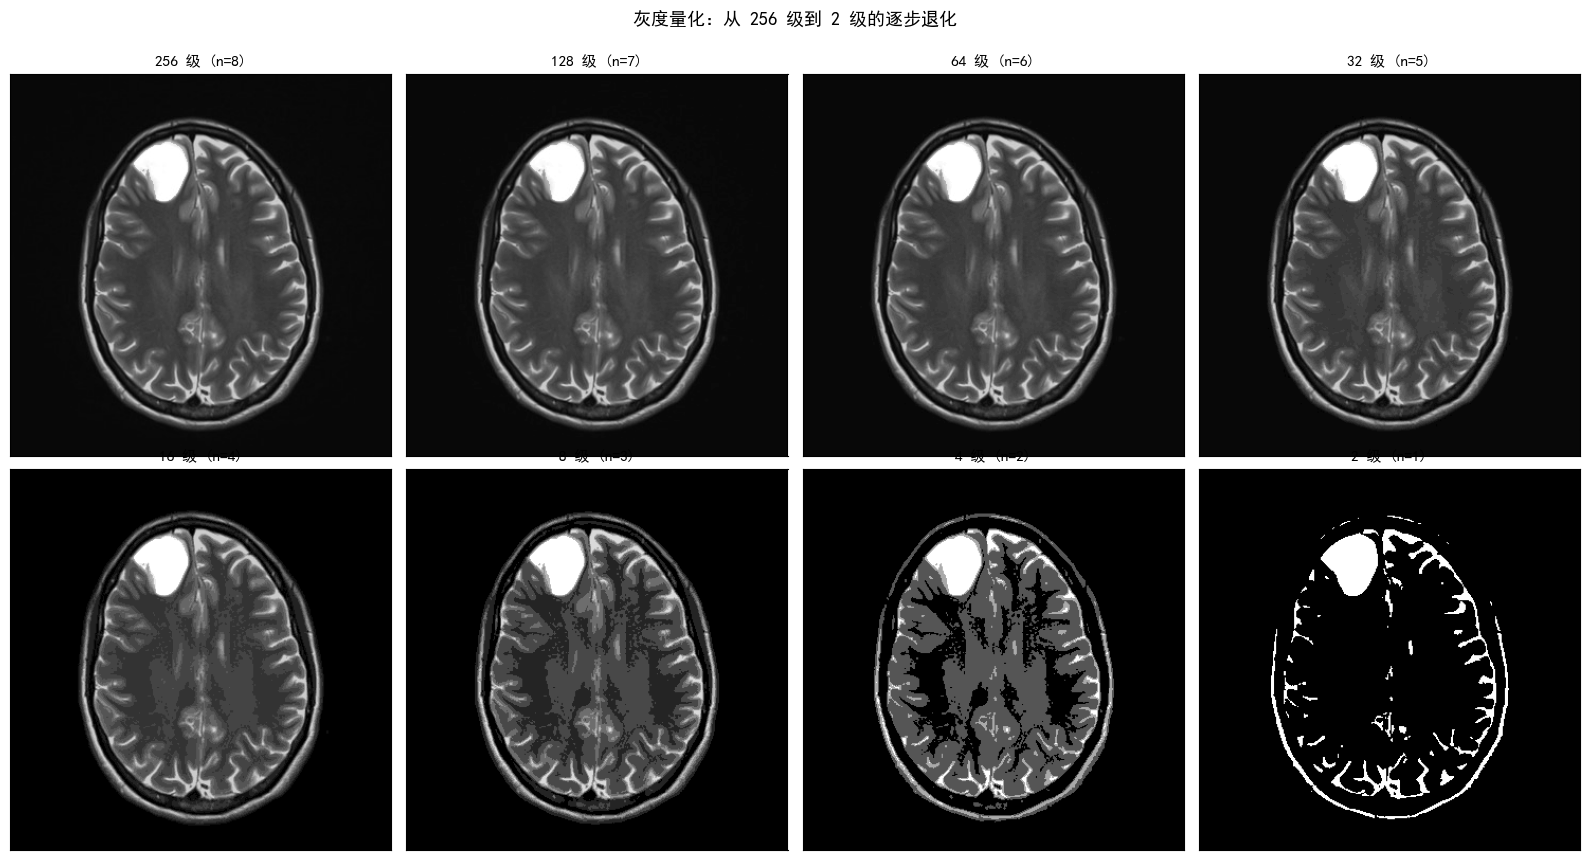

In [43]:
# ---------------------------------------------------------------------------
# 展示 n=1 到 n=8 的完整量化对比
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
axes = axes.flatten()  # 展平为一维数组方便索引

for idx, n in enumerate(range(8, 0, -1)):  # n 从 8 到 1
    num_levels = 2 ** n
    quantized_image = reduce_gray_levels(image, n)
    
    axes[idx].imshow(quantized_image, cmap='gray', vmin=0, vmax=255)
    axes[idx].set_title(f'{num_levels} 级 (n={n})', fontsize=11)
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

plt.suptitle('灰度量化：从 256 级到 2 级的逐步退化', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

观察总结：

  `n=8` (256级): 原始图像质量，无可见退化；
  
  `n=7` (128级): 几乎无区别；
  
  `n=6` (64级):  开始在灰度平缓区域出现轻微色阶；
  
  `n=5` (32级):  伪轮廓更加明显；
  
  `n=4` (16级):  明显的色块和伪轮廓；
  
  `n=3` (8级):   严重的色块效应；
  
  `n=2` (4级):   仅四种灰度，严重失真；
  
  `n=1` (2级):   仅黑白两色，变成二值图像；

## Project 3: 图像缩放（Zooming and Shrinking）

学习图像的缩小（shrinking）和放大（zooming）操作，并通过在图像中绘制一条剖面线来对比细节损失情况。

目标:
1. 读取原始图像，选定一条剖面线用于对比。
2. 将原始图像缩小为 1/N 大小（下采样/缩小）。
3. 再将缩小后的图像放大回原始大小（上采样/放大）。
4. 对比原始图像、缩小图像、放大恢复图像在同一剖面线上的灰度细节差异。

原理说明:
  缩小（Shrinking）：将图像尺寸缩小为 1/N，最简单的方法是每隔 N 个像素取一个（最近邻下采样）。这会丢失像素之间的细节信息。
  放大（Zooming）：将缩小后的图像放大回原始尺寸，常用方法有：
    - 最近邻插值（Nearest Neighbor）：直接复制最近的像素值，速度快但会产生块状效果。
    - 双线性插值（Bilinear）：用周围 4 个像素的加权平均来计算新像素值，过渡更平滑。
  经过缩小再放大后，图像会丢失高频细节，变得模糊。缩小倍数 N 越大，细节损失越严重。

**第一步：定义缩小和放大函数**

缩小函数 `shrink_image(img, N)`:
  对输入图像每隔 `N` 个像素采样一次，得到尺寸为 `(H/N, W/N)` 的小图像。
  这是最简单的下采样方式（最近邻下采样），等价于直接从原图中抽取等间隔的像素。

放大函数 `zoom_image(img, target_shape, method)`:
  将小图像放大到 `target_shape` 指定的尺寸。支持两种插值方式：
  - `nearest`（最近邻插值）：对目标图像中的每个像素，找到其在小图像中最近的对应像素，直接复制其值。
    计算方式：目标坐标 `(i,j)` 对应源坐标 `(round(i*src_h/dst_h), round(j*src_w/dst_w))`。
  - `bilinear`（双线性插值）：对目标像素的四个最近邻源像素进行加权平均，权重与距离成反比。
    产生更平滑的结果，但计算量稍大。

In [44]:
# ---------------------------------------------------------------------------
# 第一步：定义缩小和放大函数
# ---------------------------------------------------------------------------

def shrink_image(img, N):
    """
    将图像缩小为 1/N（最近邻下采样）。
    
    参数:
        img : 二维 numpy 数组，输入图像
        N   : 整数，缩小倍数
    返回:
        缩小后的图像，尺寸为 (H//N, W//N)
    
    原理: 每隔 N 个像素取一个，img[::N, ::N] 是 numpy 的步长切片语法。
    例如 N=4 时，从第 0, 4, 8, 12, ... 行和列取像素。
    """
    return img[::N, ::N]


def zoom_image(img, target_shape, method='nearest'):
    """
    将图像放大到 target_shape 指定的尺寸。
    
    参数:
        img          : 二维 numpy 数组，输入的小图像
        target_shape : 元组 (H, W)，目标输出尺寸
        method       : 插值方式，'nearest'（最近邻）或 'bilinear'（双线性）
    返回:
        放大后的图像，尺寸为 target_shape
    """
    src_h, src_w = img.shape
    dst_h, dst_w = target_shape
    
    # 为目标图像的每个像素计算其在源图像中的对应坐标
    # np.arange(dst_h) 生成 [0, 1, ..., dst_h-1]
    # 乘以 src_h/dst_h 映射回源图像坐标系
    row_coords = np.arange(dst_h) * (src_h / dst_h)
    col_coords = np.arange(dst_w) * (src_w / dst_w)
    
    if method == 'nearest':
        # 最近邻插值：四舍五入到最近的整数坐标，然后限制在合法范围内
        row_idx = np.clip(np.round(row_coords).astype(int), 0, src_h - 1)
        col_idx = np.clip(np.round(col_coords).astype(int), 0, src_w - 1)
        # 用 np.ix_ 构造网格索引，一次性提取所有目标像素
        return img[np.ix_(row_idx, col_idx)]
    
    elif method == 'bilinear':
        # 双线性插值：对四个最近邻像素进行加权平均
        output = np.zeros((dst_h, dst_w), dtype=np.float64)
        
        for i in range(dst_h):
            for j in range(dst_w):
                # 源坐标（浮点数）
                src_r = row_coords[i]
                src_c = col_coords[j]
                
                # 四个邻域像素的整数坐标
                r0 = int(np.floor(src_r))
                c0 = int(np.floor(src_c))
                r1 = min(r0 + 1, src_h - 1)
                c1 = min(c0 + 1, src_w - 1)
                
                # 计算小数部分作为插值权重
                dr = src_r - r0  # 行方向权重
                dc = src_c - c0  # 列方向权重
                
                # 双线性插值公式：
                # f(r,c) = (1-dr)(1-dc)*f(r0,c0) + (1-dr)*dc*f(r0,c1)
                #        + dr*(1-dc)*f(r1,c0) + dr*dc*f(r1,c1)
                output[i, j] = ((1 - dr) * (1 - dc) * img[r0, c0] +
                                (1 - dr) * dc       * img[r0, c1] +
                                dr       * (1 - dc) * img[r1, c0] +
                                dr       * dc       * img[r1, c1])
        
        return output.astype(np.uint8)

# 验证函数
print(f"原始图像尺寸: {image.shape}")
small = shrink_image(image.astype(np.uint8), 4)
print(f"缩小 4 倍后: {small.shape}")
restored_nn = zoom_image(small, image.shape, method='nearest')
print(f"最近邻放大恢复: {restored_nn.shape}")
restored_bl = zoom_image(small, image.shape, method='bilinear')
print(f"双线性放大恢复: {restored_bl.shape}")

原始图像尺寸: (361, 361)
缩小 4 倍后: (91, 91)
最近邻放大恢复: (361, 361)
双线性放大恢复: (361, 361)


**第二步：缩小和放大图像，展示不同 N 值的效果**

分别用 `N=2, 4, 8` 对原始图像进行缩小，然后用最近邻插值和双线性插值放大回原始尺寸。
将结果并排展示，可以直观看到：
  - `N` 越大，缩小后丢失的细节越多，放大恢复后越模糊。
  - 双线性插值比最近邻插值产生更平滑的结果，但都无法恢复已丢失的细节。
  - 最近邻插值会产生明显的块状伪影（像素块），双线性插值则更平滑但显得模糊。

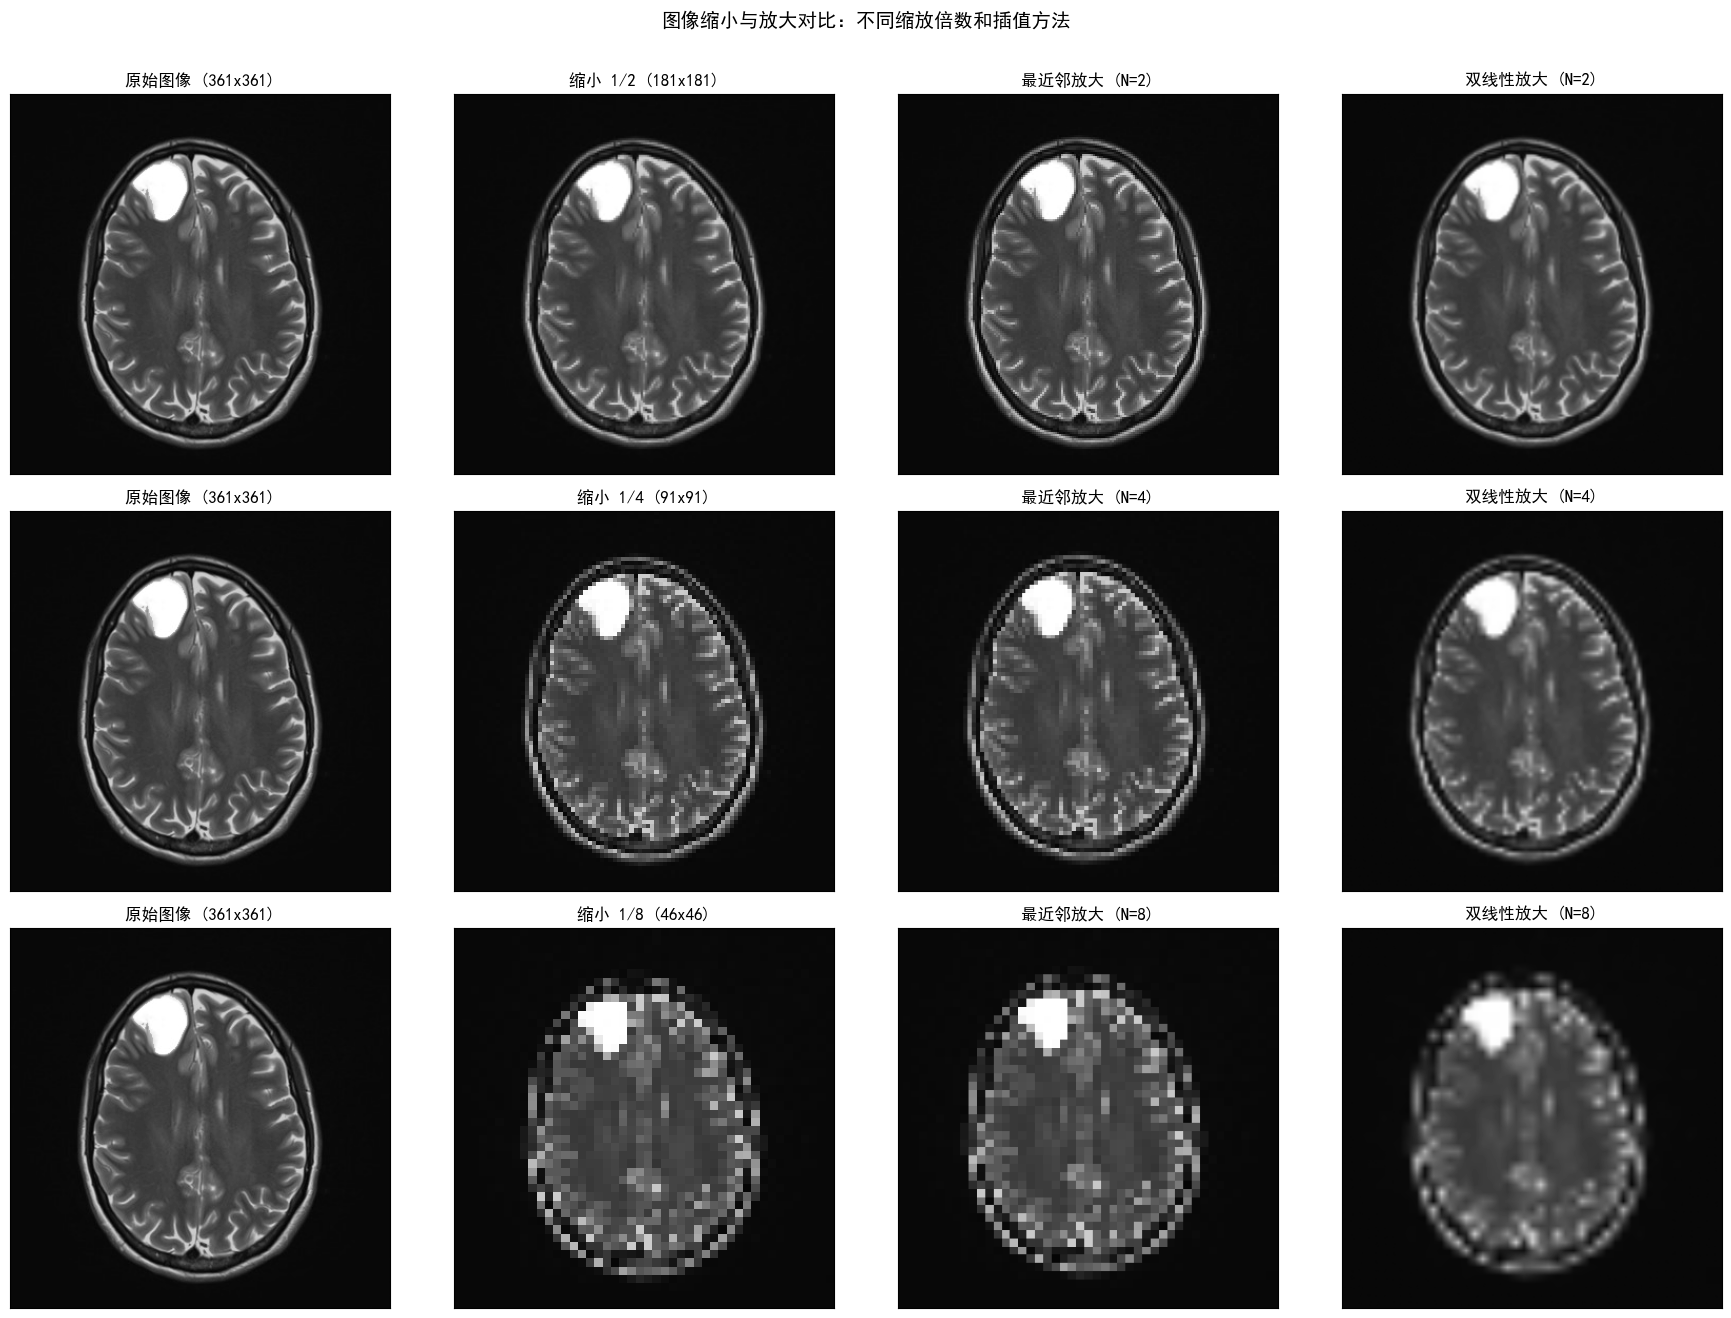

In [45]:
# ---------------------------------------------------------------------------
# 第二步：对 N=2, 4, 8 分别进行缩小和放大，展示图像对比
# ---------------------------------------------------------------------------

img_uint8 = image.astype(np.uint8)
N_values = [2, 4, 8]

fig, axes = plt.subplots(len(N_values), 4, figsize=(18, 4 * len(N_values) + 1))

for row_i, N in enumerate(N_values):
    # 缩小
    small = shrink_image(img_uint8, N)
    # 放大恢复（两种插值方式）
    restored_nn = zoom_image(small, img_uint8.shape, method='nearest')
    restored_bl = zoom_image(small, img_uint8.shape, method='bilinear')
    
    # 第 1 列：原始图像
    axes[row_i, 0].imshow(img_uint8, cmap='gray', vmin=0, vmax=255)
    axes[row_i, 0].set_title(f'原始图像 ({img_uint8.shape[0]}x{img_uint8.shape[1]})')
    
    # 第 2 列：缩小后的图像
    axes[row_i, 1].imshow(small, cmap='gray', vmin=0, vmax=255)
    axes[row_i, 1].set_title(f'缩小 1/{N} ({small.shape[0]}x{small.shape[1]})')
    
    # 第 3 列：最近邻放大恢复
    axes[row_i, 2].imshow(restored_nn, cmap='gray', vmin=0, vmax=255)
    axes[row_i, 2].set_title(f'最近邻放大 (N={N})')
    
    # 第 4 列：双线性放大恢复
    axes[row_i, 3].imshow(restored_bl, cmap='gray', vmin=0, vmax=255)
    axes[row_i, 3].set_title(f'双线性放大 (N={N})')
    
    for ax in axes[row_i]:
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('图像缩小与放大对比：不同缩放倍数和插值方法', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**第三步：绘制剖面线对比细节损失**

为了定量分析缩放过程中的细节损失，在图像中选择一条水平剖面线（某一行的所有像素灰度值），
分别绘制原始图像、缩小图像、最近邻放大恢复、双线性放大恢复的灰度变化曲线。

从剖面线可以发现：
  - 原始图像的灰度曲线有丰富的细节变化（高频分量）。
  - 缩小后的曲线点数变为 `1/N`，很多细节被采样掉了。
  - 最近邻放大恢复的曲线呈阶梯状，因为每个源像素被重复了 `N` 次。
  - 双线性放大恢复的曲线更平滑，但无法恢复原始的高频细节。
  - `N` 越大，恢复后的曲线与原始曲线差距越大。

剖面线位置：第 180 行（图像中间）


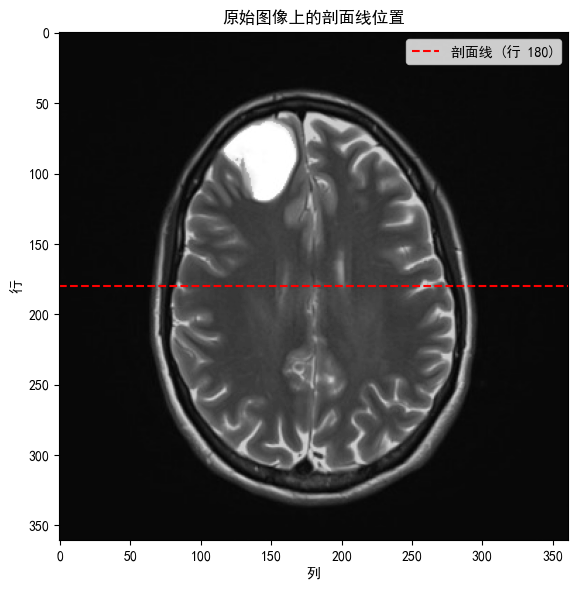

In [46]:
# ---------------------------------------------------------------------------
# 第三步：在图像上绘制剖面线位置，并对比灰度曲线
# ---------------------------------------------------------------------------

# 选择图像中间行作为剖面线
line_row = img_uint8.shape[0] // 2
print(f"剖面线位置：第 {line_row} 行（图像中间）")

# 先展示剖面线在原始图像上的位置
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_uint8, cmap='gray', vmin=0, vmax=255)
ax.axhline(y=line_row, color='red', linewidth=1.5, linestyle='--', label=f'剖面线 (行 {line_row})')
ax.legend(loc='upper right', fontsize=10)
ax.set_title('原始图像上的剖面线位置')
ax.set_xlabel('列')
ax.set_ylabel('行')
plt.tight_layout()
plt.show()

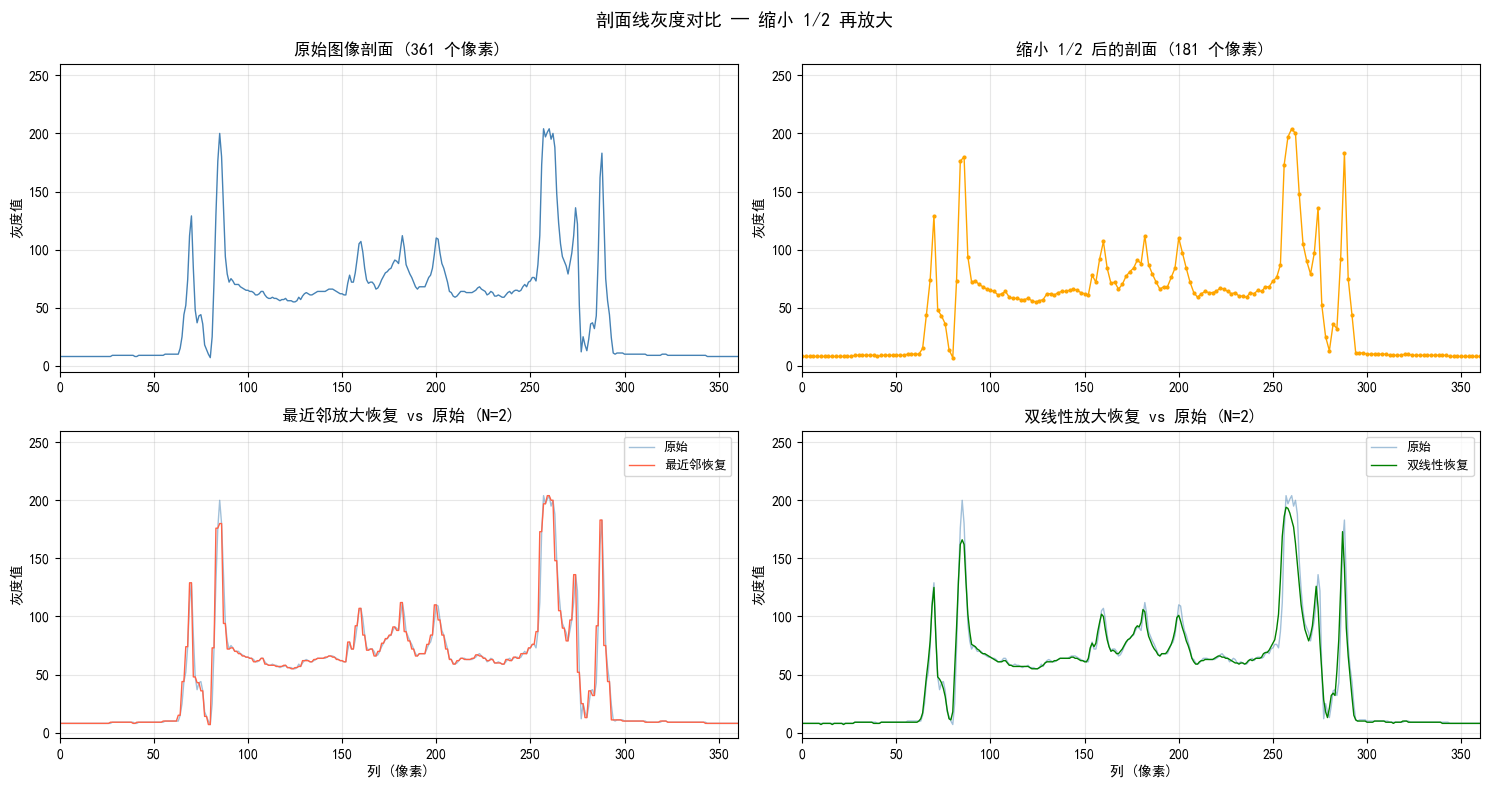

N=2: 最近邻恢复的均方误差(MSE) = 78.95
N=2: 双线性恢复的均方误差(MSE) = 72.70



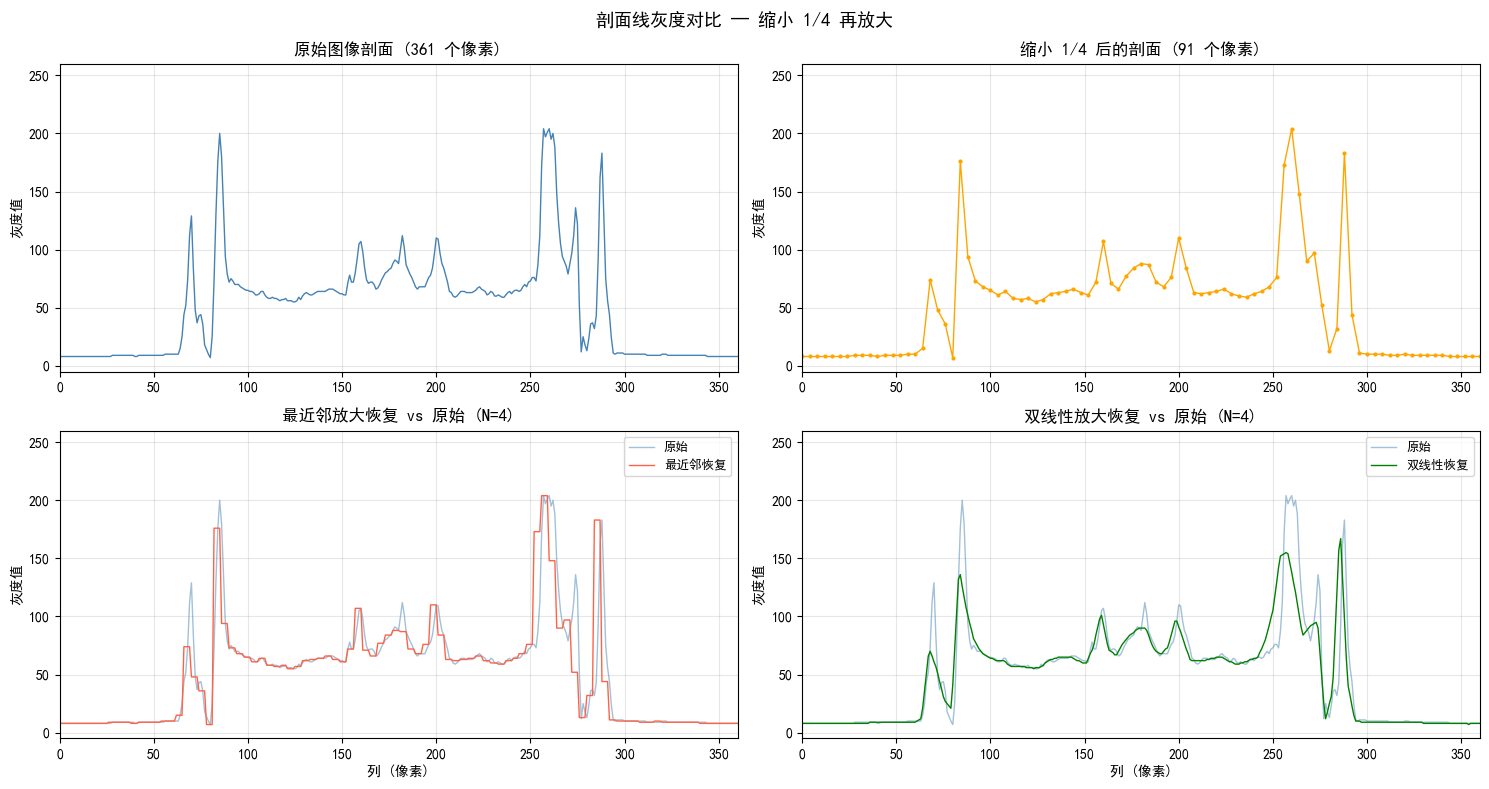

N=4: 最近邻恢复的均方误差(MSE) = 519.18
N=4: 双线性恢复的均方误差(MSE) = 356.47



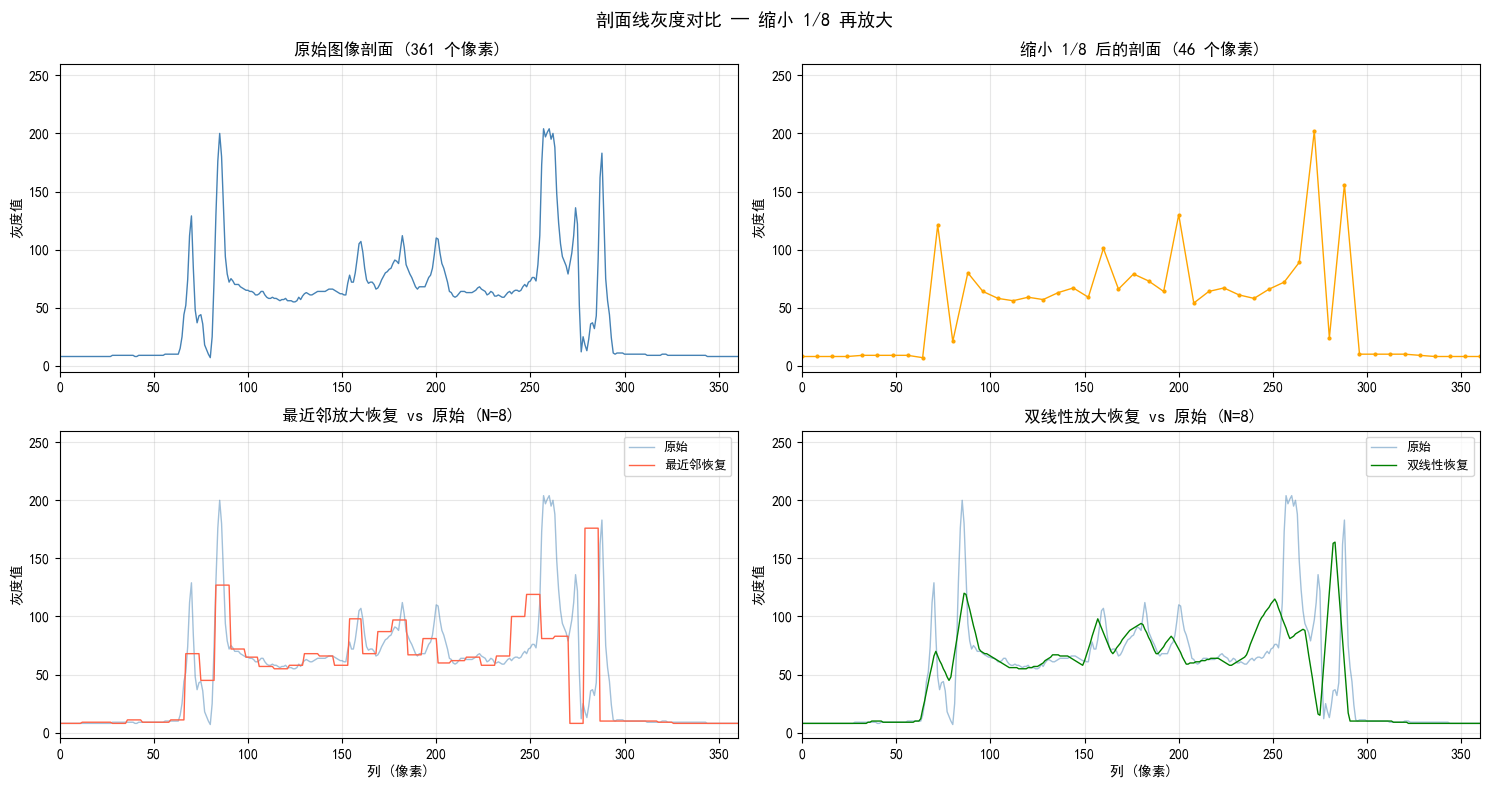

N=8: 最近邻恢复的均方误差(MSE) = 1307.63
N=8: 双线性恢复的均方误差(MSE) = 930.41



In [47]:
# ---------------------------------------------------------------------------
# 对每个 N 值绘制剖面线灰度对比曲线
# ---------------------------------------------------------------------------

for N in N_values:
    # 缩小
    small = shrink_image(img_uint8, N)
    # 放大恢复
    restored_nn = zoom_image(small, img_uint8.shape, method='nearest')
    restored_bl = zoom_image(small, img_uint8.shape, method='bilinear')
    
    # 提取剖面线数据
    original_line = img_uint8[line_row, :]                        # 原始图像剖面
    small_line = small[line_row // N, :]                          # 缩小图像对应行的剖面
    restored_nn_line = restored_nn[line_row, :]                   # 最近邻恢复剖面
    restored_bl_line = restored_bl[line_row, :]                   # 双线性恢复剖面
    
    # 缩小图像的 x 坐标需要对应到原图坐标系（每隔 N 个像素一个采样点）
    small_x = np.arange(len(small_line)) * N
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    
    # 左上：原始图像剖面
    axes[0, 0].plot(original_line, color='steelblue', linewidth=1)
    axes[0, 0].set_title(f'原始图像剖面 ({len(original_line)} 个像素)')
    axes[0, 0].set_xlim(0, len(original_line) - 1)
    axes[0, 0].set_ylim(-5, 260)
    axes[0, 0].set_ylabel('灰度值')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 右上：缩小图像剖面
    axes[0, 1].plot(small_x, small_line, color='orange', linewidth=1, marker='o', markersize=2)
    axes[0, 1].set_title(f'缩小 1/{N} 后的剖面 ({len(small_line)} 个像素)')
    axes[0, 1].set_xlim(0, len(original_line) - 1)
    axes[0, 1].set_ylim(-5, 260)
    axes[0, 1].set_ylabel('灰度值')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 左下：最近邻放大剖面 vs 原始
    axes[1, 0].plot(original_line, color='steelblue', linewidth=1, alpha=0.5, label='原始')
    axes[1, 0].plot(restored_nn_line, color='tomato', linewidth=1, label='最近邻恢复')
    axes[1, 0].set_title(f'最近邻放大恢复 vs 原始 (N={N})')
    axes[1, 0].set_xlim(0, len(original_line) - 1)
    axes[1, 0].set_ylim(-5, 260)
    axes[1, 0].set_xlabel('列 (像素)')
    axes[1, 0].set_ylabel('灰度值')
    axes[1, 0].legend(fontsize=9)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 右下：双线性放大剖面 vs 原始
    axes[1, 1].plot(original_line, color='steelblue', linewidth=1, alpha=0.5, label='原始')
    axes[1, 1].plot(restored_bl_line, color='green', linewidth=1, label='双线性恢复')
    axes[1, 1].set_title(f'双线性放大恢复 vs 原始 (N={N})')
    axes[1, 1].set_xlim(0, len(original_line) - 1)
    axes[1, 1].set_ylim(-5, 260)
    axes[1, 1].set_xlabel('列 (像素)')
    axes[1, 1].set_ylabel('灰度值')
    axes[1, 1].legend(fontsize=9)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(f'剖面线灰度对比 — 缩小 1/{N} 再放大', fontsize=13)
    plt.tight_layout()
    plt.show()
    
    # 计算误差
    mse_nn = np.mean((original_line.astype(float) - restored_nn_line.astype(float)) ** 2)
    mse_bl = np.mean((original_line.astype(float) - restored_bl_line.astype(float)) ** 2)
    print(f"N={N}: 最近邻恢复的均方误差(MSE) = {mse_nn:.2f}")
    print(f"N={N}: 双线性恢复的均方误差(MSE) = {mse_bl:.2f}")
    print()

对比分析可以看出缩小再放大后结果和原始图像之间的差异，双线性放大恢复相比最近邻放大有更多的尖角并且恢复的拟合效果更好。

**第四步：局部细节放大对比**

为了更直观地观察缩放带来的细节损失，截取图像的一个小区域（例如左上角 64x64 像素），
对比原始图像和经过缩小+放大后的结果。这样可以在局部尺度上清楚看到像素级别的差异。

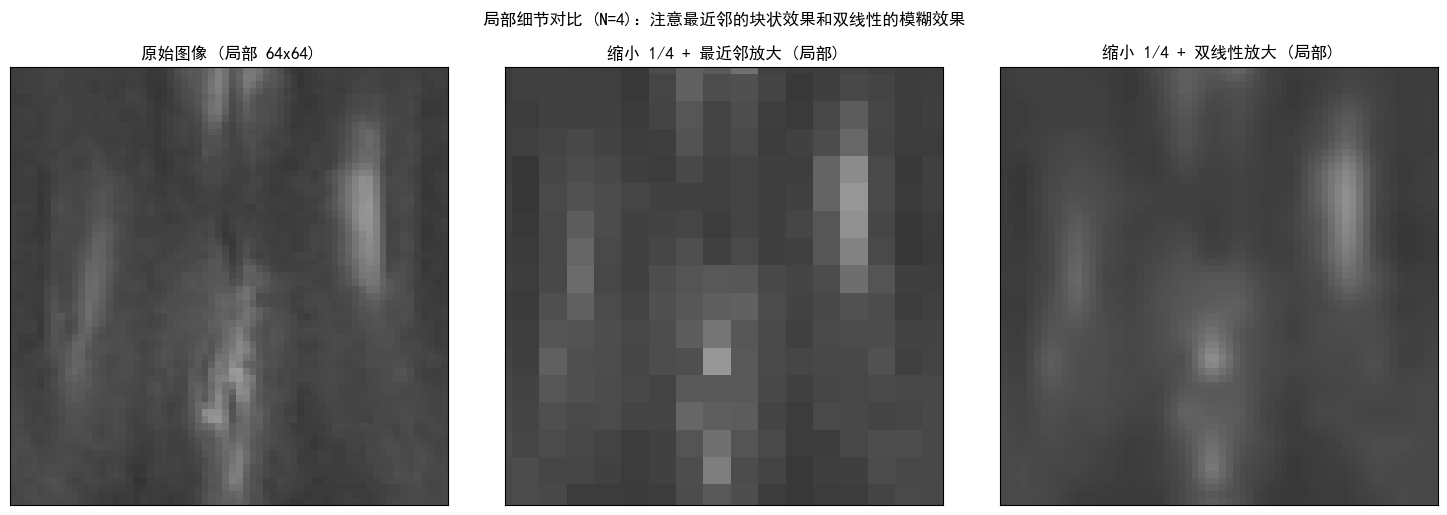

In [48]:
# ---------------------------------------------------------------------------
# 第四步：局部区域细节对比
# ---------------------------------------------------------------------------

# 选取图像中心附近的一个 64x64 区域
h, w = img_uint8.shape
r_start, c_start = h // 2 - 32, w // 2 - 32
r_end, c_end = r_start + 64, c_start + 64

N = 4  # 以 N=4 为例展示局部细节

small = shrink_image(img_uint8, N)
restored_nn = zoom_image(small, img_uint8.shape, method='nearest')
restored_bl = zoom_image(small, img_uint8.shape, method='bilinear')

# 截取局部区域
crop_orig = img_uint8[r_start:r_end, c_start:c_end]
crop_nn = restored_nn[r_start:r_end, c_start:c_end]
crop_bl = restored_bl[r_start:r_end, c_start:c_end]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(crop_orig, cmap='gray', vmin=0, vmax=255, interpolation='none')
axes[0].set_title('原始图像 (局部 64x64)')

axes[1].imshow(crop_nn, cmap='gray', vmin=0, vmax=255, interpolation='none')
axes[1].set_title(f'缩小 1/{N} + 最近邻放大 (局部)')

axes[2].imshow(crop_bl, cmap='gray', vmin=0, vmax=255, interpolation='none')
axes[2].set_title(f'缩小 1/{N} + 双线性放大 (局部)')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(f'局部细节对比 (N={N})：注意最近邻的块状效果和双线性的模糊效果', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

观察以上图像总结：

  原始图像包含丰富的细节和边缘信；  缩小 1/4 再放大后，高频细节（边缘、纹理）被不可逆地丢；
  最近邻插值产生清晰但块状的伪影（像素；
  双线性插值过渡更平滑，但图像整体变得模糊

## Project 4: 颜色叠加（Color Overlay）

学习如何通过阈值分割生成二值掩膜（mask），然后将掩膜作为红色通道叠加到原始灰度图像上，
生成一幅彩色叠加图像。这种技术在医学影像、目标检测等领域中非常常用，可以直观地标记出感兴趣的区域。

目标:
1. 对灰度图像进行阈值分割：当像素值 `I > threshold` 时，掩膜为 1（白），否则为 0（黑）。
2. 将原始灰度图像转换为三通道 RGB 图像。
3. 将掩膜叠加到红色通道（R 通道），生成颜色叠加效果。
4. 尝试不同的阈值，观察分割和叠加效果的变化。

原理说明:
  阈值分割是最简单的图像分割方法。给定一个阈值 T，对图像中的每个像素 I(r,c)：
    当 `I(r,c) > T`    `mask(r,c) = 1`；
    当 `I(r,c) <= T`    `mask(r,c) = 0`；
    掩膜标记了所有灰度值大于阈值的"亮区域"。

  颜色叠加的原理：
    灰度图像只有一个通道，而 RGB 彩色图像有三个通道（红R、绿G、蓝B）。
    先将灰度图像复制到 RGB 三个通道（此时图像看起来仍然是灰色的），
    然后在掩膜区域将红色通道的值设为 255（最大红色），
    这样掩膜区域就会显示为红色叠加效果，非掩膜区域仍为原始灰度。

**第一步：通过阈值生成二值掩膜**

对原始灰度图像应用阈值 `T`，生成二值掩膜 mask：
  `mask(r,c) = True`  当 `I(r,c) > T`
  `mask(r,c) = False` 当 `I(r,c) <= T`

先选择一个中间阈值 `T=128` 来演示，然后展示掩膜的效果。
掩膜图像中白色区域表示灰度值大于阈值的像素，黑色区域表示灰度值小于等于阈值的像素。

阈值: 128
掩膜形状: (361, 361)
掩膜数据类型: bool
大于阈值的像素数: 7325 (5.6%)
小于等于阈值的像素数: 122996 (94.4%)


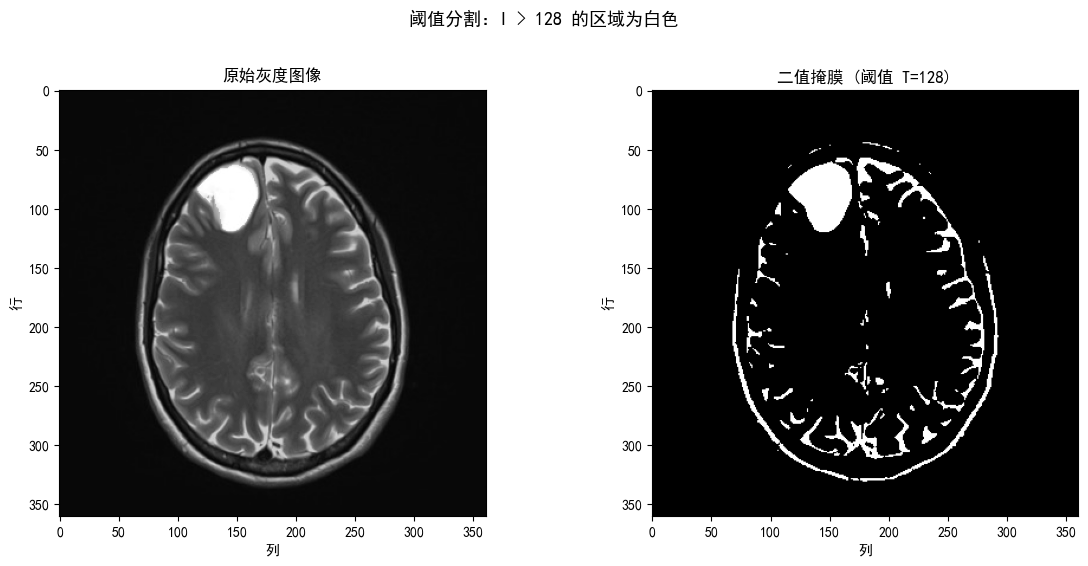

In [49]:
# ---------------------------------------------------------------------------
# 第一步：通过阈值生成二值掩膜
# ---------------------------------------------------------------------------

threshold = 128  # 阈值，可以调整

# 生成掩膜：像素值 > threshold 的位置为 True，否则为 False
# image 在单元 2 中已加载为 float64，这里直接使用
mask = image > threshold

print(f"阈值: {threshold}")
print(f"掩膜形状: {mask.shape}")
print(f"掩膜数据类型: {mask.dtype}")
print(f"大于阈值的像素数: {np.sum(mask)} ({np.sum(mask) / mask.size * 100:.1f}%)")
print(f"小于等于阈值的像素数: {np.sum(~mask)} ({np.sum(~mask) / mask.size * 100:.1f}%)")

# 并排显示原始图像和掩膜
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('原始灰度图像')
axes[0].set_xlabel('列')
axes[0].set_ylabel('行')

# 掩膜以白色(True=255)和黑色(False=0)显示
axes[1].imshow(mask.astype(np.uint8) * 255, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'二值掩膜 (阈值 T={threshold})')
axes[1].set_xlabel('列')
axes[1].set_ylabel('行')

plt.suptitle(f'阈值分割：I > {threshold} 的区域为白色', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**第二步：将掩膜叠加到红色通道，生成彩色叠加图像**

具体步骤：
  1. 将灰度图像从单通道 `(H, W)` 扩展为三通道 RGB 图像 `(H, W, 3)`。
     方法是用 `np.stack` 将同一幅灰度图像复制三次，分别作为 R、G、B 通道。
     此时图像看起来仍然是灰色的，因为三个通道的值完全相同。
  2. 在掩膜为 `True` 的区域，将红色通道设为 255，同时将绿色和蓝色通道设为 0。
     注意：如果只设置 `R=255` 而不改动 G 和 B，那么原本灰度值很高的像素
     （例如灰度 250）会变成 `RGB=(255,250,250)`，三个通道值都接近最大值，
     显示出来是白色而不是红色。因此必须同时将 G 和 B 设为 0，
     使掩膜区域呈现纯红色 `RGB=(255,0,0)`。
  3. `imshow` 会自动将三通道数组识别为 RGB 彩色图像进行显示。

叠加图像形状: (361, 361, 3)  (高, 宽, RGB三通道)
叠加图像数据类型: uint8


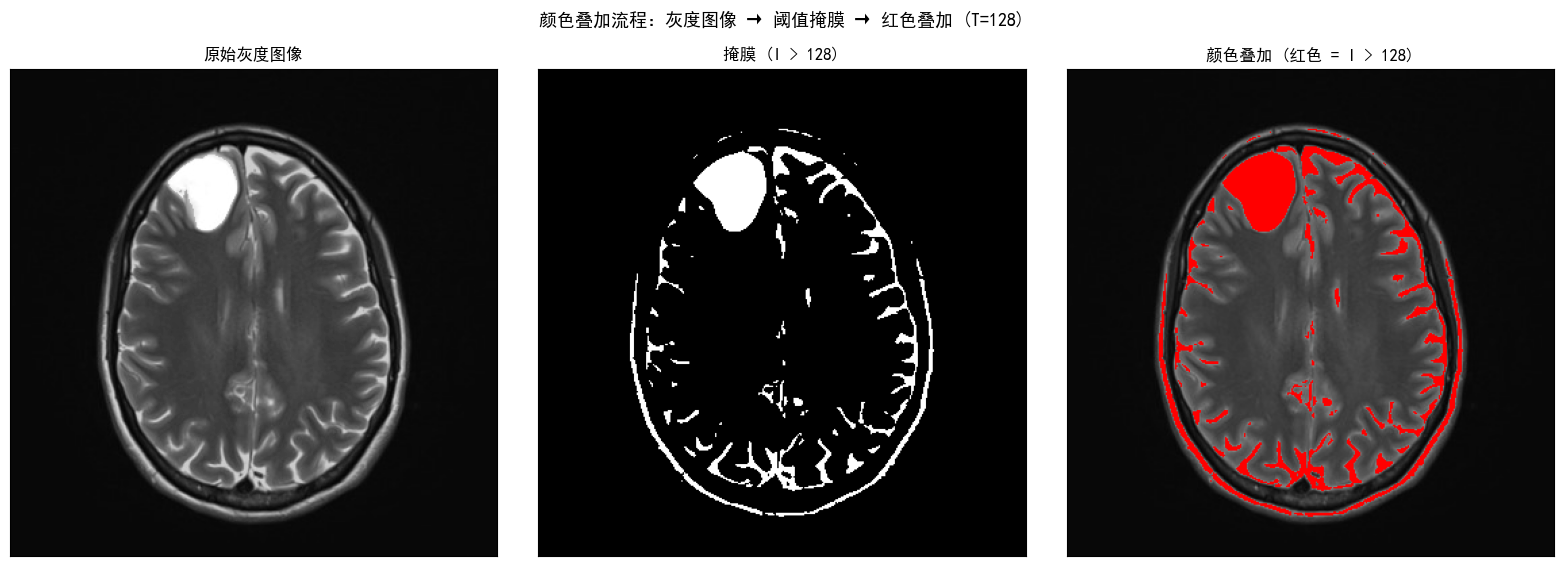

In [50]:
# ---------------------------------------------------------------------------
# 第二步：生成颜色叠加图像（掩膜区域显示为红色）
# ---------------------------------------------------------------------------

def color_overlay(gray_img, mask):
    """
    将二值掩膜以红色叠加到灰度图像上。
    
    参数:
        gray_img : 二维数组，灰度图像（0-255）
        mask     : 二维布尔数组，True 表示需要标记的区域
    返回:
        overlay  : 三维数组 (H, W, 3)，RGB 彩色叠加图像
    """
    img = gray_img.astype(np.uint8)
    
    # 步骤 1: 将灰度图像扩展为三通道 RGB
    # np.stack 沿 axis=2 堆叠三个相同的灰度图，形成 (H, W, 3)
    # 通道顺序：[R, G, B] = [灰度, 灰度, 灰度]
    overlay = np.stack([img, img, img], axis=2)
    
    # 步骤 2: 在掩膜区域将红色通道设为 255，同时将绿色和蓝色通道设为 0
    overlay[mask, 0] = 255  # R 通道设为最大值
    overlay[mask, 1] = 0    # G 通道设为 0
    overlay[mask, 2] = 0    # B 通道设为 0
    
    return overlay

# 生成颜色叠加图像
overlay_img = color_overlay(image, mask)

print(f"叠加图像形状: {overlay_img.shape}  (高, 宽, RGB三通道)")
print(f"叠加图像数据类型: {overlay_img.dtype}")

# 展示结果：原始图像、掩膜、颜色叠加
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

axes[0].imshow(image.astype(np.uint8), cmap='gray', vmin=0, vmax=255)
axes[0].set_title('原始灰度图像')

axes[1].imshow(mask.astype(np.uint8) * 255, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'掩膜 (I > {threshold})')

axes[2].imshow(overlay_img)
axes[2].set_title(f'颜色叠加 (红色 = I > {threshold})')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(f'颜色叠加流程：灰度图像 → 阈值掩膜 → 红色叠加 (T={threshold})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**第三步：不同阈值的颜色叠加对比**

为了更全面地理解阈值选择对分割结果的影响，尝试多个不同的阈值（64, 128, 192），
观察掩膜覆盖区域和颜色叠加效果的变化。

  - 阈值较低（如 64）：大部分像素都超过阈值，红色覆盖范围很大。
  - 阈值适中（如 128）：大约一半的像素被标记为红色。
  - 阈值较高（如 192）：只有最亮的区域被标记为红色，覆盖范围很小。

注意：每个阈值对应的叠加图像都调用了 `color_overlay` 函数，该函数在掩膜区域同时设置
`R=255`、`G=0`、`B=0`，确保无论原始灰度值高低，标记区域始终显示为纯红色而非白色。

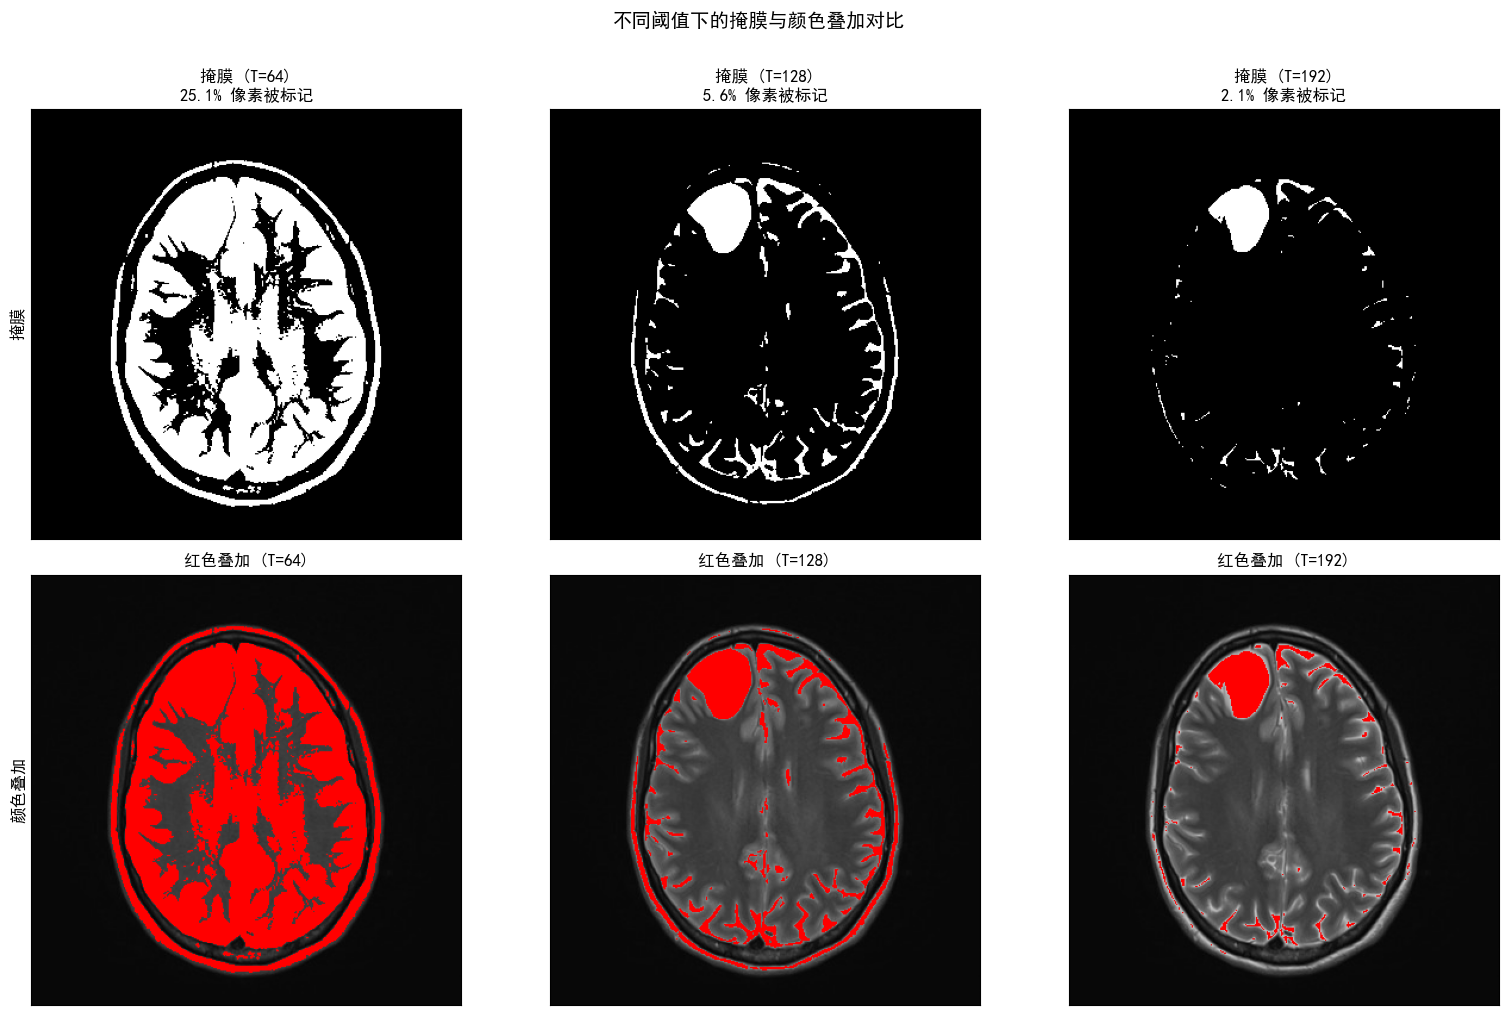

In [51]:
# ---------------------------------------------------------------------------
# 第三步：不同阈值的颜色叠加对比
# ---------------------------------------------------------------------------

thresholds = [64, 128, 192]

fig, axes = plt.subplots(2, len(thresholds), figsize=(16, 10))

for col_i, T in enumerate(thresholds):
    # 生成掩膜：像素值 > T 的位置为 True
    m = image > T
    pct = np.sum(m) / m.size * 100
    
    # 上行：掩膜（白色=被标记区域，黑色=未标记区域）
    axes[0, col_i].imshow(m.astype(np.uint8) * 255, cmap='gray', vmin=0, vmax=255)
    axes[0, col_i].set_title(f'掩膜 (T={T})\n{pct:.1f}% 像素被标记')
    axes[0, col_i].set_xticks([])
    axes[0, col_i].set_yticks([])
    
    # 下行：颜色叠加（掩膜区域 R=255, G=0, B=0 → 纯红色）
    overlay = color_overlay(image, m)
    axes[1, col_i].imshow(overlay)
    axes[1, col_i].set_title(f'红色叠加 (T={T})')
    axes[1, col_i].set_xticks([])
    axes[1, col_i].set_yticks([])

axes[0, 0].set_ylabel('掩膜', fontsize=12)
axes[1, 0].set_ylabel('颜色叠加', fontsize=12)

plt.suptitle('不同阈值下的掩膜与颜色叠加对比', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

观察得出结论：

  阈值越低，被标记（红色）的区域越大，包含了更多较暗的像素；阈值越高，被标记的区域越小，只有最亮的区域被标记为红色；选择合适的阈值取决于具体应用场景和图像的灰度分布。